# Data Science I
<div style="position: relative;">
    <div style="position: absolute; top: -60px; right: 10px; padding: 5px; background-color: transparent; font-size: 20px; text-align: right;">
        <span>Version: October 10, 2025</span>
    </div>
</div>

## Project Report: Predicting Energy Prices
<span style="font-weight: bold; text-decoration: underline;">Submission Deadline: January 25 2026, 21:00 UTC</span>
    
**University of Oldenburg**<br/>
**Winter 2025/2026**<br/>
**Instructors**: [Jannik Schröder](https://uol.de/team-data/jannik-schroeder), [Wolfram "Wolle" Wingerath](https://uol.de/wolle)

<span style="font-weight: bold; ">Submitted by: <span style="color: red;">Kryvtsova Vlada, Winkler David, Brüning Menko</span>

---

# Introduction
Electricity markets require generators, traders, and large consumers to plan production and consumption ahead of time. In Europe, one of the most important reference markets is the **day-ahead market**, where participants submit bids and offers for each delivery hour of the next day. The market is then cleared so that supply meets demand, resulting in a separate hourly price (€/MWh) for each hour of the following day. These prices can vary strongly due to demand patterns, renewable generation, fuel costs, and seasonal effects, and they may even become negative during periods of high renewable supply and low demand.

The goal of this project is to forecast Germany’s day-ahead electricity prices for a specific target date, **January 27, 2026**, using historical data from 2018–2025. We frame the task as an **hourly supervised forecasting problem** with the target variable being the price for delivery hour *t*. As explanatory variables, we use a compact set of drivers available in our dataset. Some of them are the previous day’s price, forecasts for load, wind and solar generation, calendar variables.

To assess the value of increasing model complexity, we implement and compare four levels of models: 
*  **Level 0**: naive persistence baseline (“tomorrow equals yesterday”)
*  **Level 1**: seasonal time-series model (SARIMA)
*  **Level 2**: linear regression model using multiple features
*  **Level 3**: machine-learning model (XGBoost).

Models are evaluated with time-aware splits and standard error metrics to ensure a fair comparison without information leakage. The report presents the dataset, modeling choices, evaluation methodology, and results, and concludes with limitations and potential improvements for future work.

<a id="data-preprocessing"></a>
# Part 1. Gathering Data Sources

## 1.1 Time span
The dataset used in this project combines several time series that are relevant for explaining and forecasting German day-ahead electricity prices. The sourced data covers the period **from October 10, 2018 to <span style="color: red;">December 14, 2025**</span> with an hourly resolution. This time span is sufficiently long to support robust model training and evaluation, while capturing both structural trends and exceptional market conditions. In particular, the price spike in 2022 visible in the figure below reflects a short-lived geopolitical shock, triggered by Russia’s reduction of natural gas supplies to Europe.\
\
Including such extreme but historically significant events allows the model to learn how electricity prices respond to rare disruptions. This reduces the risk of misinterpreting these dynamics as random noise and improves generalization under stress scenarios.

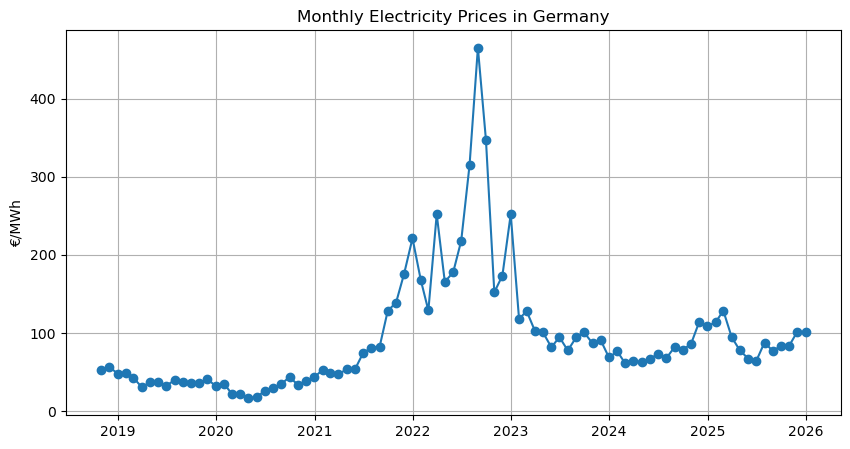

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
electricity_prices = pd.read_csv("datasets/smard_data_2018-2025.csv")
electricity_prices = electricity_prices.set_index('Datum')
electricity_prices.index = pd.to_datetime(electricity_prices.index,  format="%d.%m.%Y %H:%M")
electricity_prices.head()
monthly_prices = electricity_prices["Day-Ahead Preis DE/LU"].resample("ME").mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_prices, marker='o')
plt.title("Monthly Electricity Prices in Germany")
plt.ylabel("€/MWh")
plt.grid(True)
plt.show()

## 1.2 Data Parameters & Sources
Our data parameters are day-ahead electricity prices for Germany, load forecasts, wind/solar generation forecasts and a gas price series. This data was sourced from **[source of day-ahead prices]**.\
\
To capture weather-driven demand and renewable patterns, we additionally sourced hourly weather data for Hamburg, Berlin, Köln, München, Leipzig, and Frankfurt from **[weather data source]**. 

<span style="color: red;">Combine two datasets here, explain steps and show a couple of rows. Name the combined dataframe as df, so that the code below works.</span> 

<span style="color: red;">Explain the meaning of each column (emphasis on which data is forecasted and which one is realized). </span> 


## 1.3 Data Cleaning

To clean the data we will start by identifying the missing values. 

In [2]:
import numpy as np
df = pd.read_csv("datasets/combined_data_2018-2025.csv")
df = df.set_index('datetime')
s = "____________________________________________________________________________________________________"
df.index = pd.to_datetime(df.index)
print("Identifying null values...")
print(s)
print(df.info())

Identifying null values...
____________________________________________________________________________________________________
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 63137 entries, 2018-10-01 00:00:00 to 2025-12-14 09:00:00
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   solar_production_mwh     63137 non-null  float64
 1   gas_production_mwh       63137 non-null  float64
 2   wind_production_mwh      63137 non-null  float64
 3   day_ahead_price          63137 non-null  float64
 4   load_forecast_mwh        63137 non-null  object 
 5   temperature_avg          63137 non-null  float64
 6   wind_speed_avg           63137 non-null  float64
 7   shortwave_radiation_avg  63137 non-null  float64
dtypes: float64(7), object(1)
memory usage: 4.3+ MB
None


At the first glance the dataset seems to have no missing values. However, after having taken a closer look at the *load_forecast_mwh* column, which is a representation of the forecasted electricity demand, a lot of missing values marked with a dash (-) had been identified. Therefore, the next step is to eliminate them. 

One of the best ways to handle missing values in time series is time-series interpolation. It is a method to estimate missing values using nearby known values. It assumes the variable changes smoothly over time and estimates missing points from neighboring timestamps, making it suitable for short gaps in continuous, ordered data. That being said, we firstly need to examine *load_forecast_mwh* to see whether it follows a particular trend.

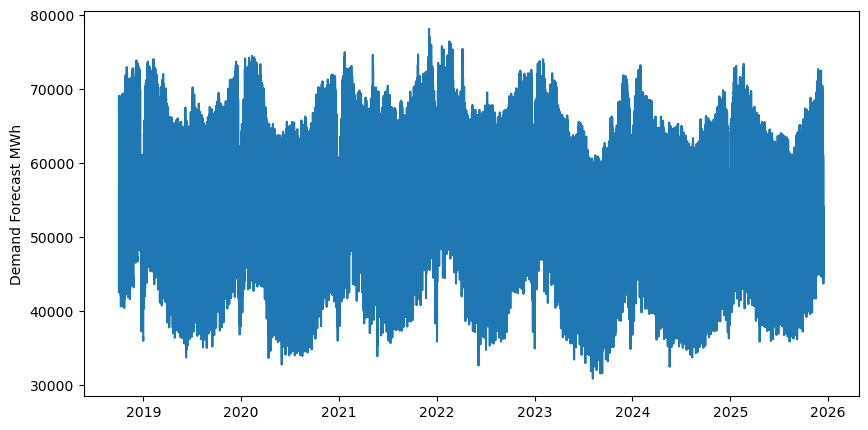

In [3]:
# replace '-' with NaN to identify missing data in the forecasted demand
# convert object to float
df["load_forecast_mwh"] = (
    df["load_forecast_mwh"]
    .replace("-", np.nan)
    .astype(float)
)

plt.figure(figsize=(10, 5))
plt.plot(df.index, df["load_forecast_mwh"])
plt.ylabel("Demand Forecast MWh")
plt.show()

**Conclusion:** There is a strong seasonal trend. Fluctuations are smooth and continious. Therefore, for this case time-based interpolation is a good choice to handle missing values.

In [4]:
# apply time-based interpolation
df["load_forecast_mwh"] = (
    df["load_forecast_mwh"]
    .interpolate(method="time")
)
df.head()

,solar_production_mwh,gas_production_mwh,wind_production_mwh,day_ahead_price,load_forecast_mwh,temperature_avg,wind_speed_avg,shortwave_radiation_avg
datetime,,,,,,,,
2018-10-01 00:00:00,0.0,3391.75,5886.50,59.53,NaN,9.186501,6.818659,0.0
2018-10-01 01:00:00,0.0,3257.50,6055.25,56.10,NaN,9.578167,6.990562,0.0
2018-10-01 02:00:00,0.0,3336.50,6034.00,51.41,42628.00,9.128166,9.090224,0.0
2018-10-01 03:00:00,0.0,3179.50,6300.50,47.38,42986.75,8.486500,7.525046,0.0
2018-10-01 04:00:00,0.0,3370.75,7117.50,47.59,44675.00,7.994833,8.720925,0.0


Since time-based interpolation is not able to impute values for the first 2 columns (no timestamps before available), the simplest way would be to delete them.

In [29]:
df = df.iloc[2:, :]
df.head()

,solar_production_mwh,gas_production_mwh,wind_production_mwh,day_ahead_price,load_forecast_mwh,temperature_avg,wind_speed_avg,shortwave_radiation_avg
datetime,,,,,,,,
2018-10-01 04:00:00,0.00,3370.75,7117.50,47.59,44675.00,7.994833,8.720925,0.000000
2018-10-01 05:00:00,0.00,3655.25,7842.50,51.61,48813.25,8.028167,9.275947,0.000000
2018-10-01 06:00:00,0.00,4758.75,9506.25,69.13,57869.00,8.078166,9.183099,0.000000
2018-10-01 07:00:00,208.25,5603.75,10531.50,77.32,63091.50,8.028167,8.665720,0.000000
2018-10-01 08:00:00,2009.50,5656.25,10703.50,84.97,65697.25,8.519834,9.125841,9.833333


> Note: Zero values are actual legitimate values that represent no production (e.g. no solar energy production during the night).

# Part 2. Exploratory Data Analysis

## 2.1 Statistical summaries

## 2.2 Investigation of Relationships 


### Demand <-> Price 
Firstly, we will look at how the forecasted demand correlates with actual day-ahead electricity prices. 

In [26]:
spearman_corr, _ = stats.spearmanr(df['load_forecast_mwh'], df['day_ahead_price'])
pearson_corr = df['load_forecast_mwh'].corr(df['day_ahead_price'])
print(f"Pearson rank corr: {pearson_corr}")
print(s)
print(f"Spearman rank corr: {spearman_corr}")

Pearson rank corr: 0.18137591606092246
____________________________________________________________________________________________________
Spearman rank corr: 0.2074318017348293


**Interpretation:** higher expected demand tends to coincide with higher prices, but demand alone explains only a limited part of price variation (weak correlation). Electricity prices correlate more with residual load, since demand on isolation does not imply much information (e.g. high demand with high renewables would not result in higher prices; moderate demand with low renewables could still result in high prices). Additionally, fuel prices, imports, bidding behavior add noise.

### (Demand & Renewables) <-> Price
Now, we will look at how the forecasted demand correlates with <span style="color: red;">actual (we need FORECASTED)</span> energy production from renewables using the formula for residual load. Residual load is the part of electricity demand that remains after subtracting variable renewable generation. The formula for hour *t* is
$$\text{Residual Load}_{t} = \text{Load}_{t} - \text{Wind}_{t} - \text{Solar}_{t}$$
High residual load means that renewables cower little of demand. Therefore, more conventional plants are needed, which results in higher electricity prices. It works the opposite way for low residual load, since in this case renewables cower most/all demand. \
\
This implies that residual load should strongly correlate with electricity prices. So, this is what we'll be testing next using **Spearman's rank** correlation. This correlation type is better suited for electricity price analysis because it captures monotonic but nonlinear relationships and is robust to extreme price spikes (e.g. sharp price spikes during scarcity events).

In [27]:
from scipy import stats
residual_load = df['load_forecast_mwh'] - df['solar_production_mwh'] - df['wind_production_mwh']
corr, _ = stats.spearmanr(df['day_ahead_price'], residual_load)
print(f"Correlation between electricity prices and residual load: {corr}")
print(s)

Correlation between electricity prices and residual load: 0.48419120582616426
____________________________________________________________________________________________________


**Interpretation:** The residual load shows a moderate to strong positive correlation with day-ahead prices. This indicates that higher residual load leads to higher day-ahead electricity. Even though substantial variability still remains due to unexplained market, fuel, and network effects, correlation rate of 0.48 motivates adding Residual Load as a model parameter.

### Demand <-> Weather

Next we will look at how <span style="color: red;">actual (IS IT ACTUAL OR FORECASTED? We need forecasted)</span> weather correlates with forecasted demand. In this case we would expect the correlation index to be very low. This is because the relationship between these two variales is non-linear. Intuitively it is expected that cold weather leads to higher electricity prices (heating demand), as well as hot weather (cooling demand), while mild weather results in lower prices. So, it is better to investigate this relationship separately for hot and cold weather.

In [28]:
print(f"Demand to weather correlation: {df['load_forecast_mwh'].corr(df['temperature_avg'])}")
print(s)
cold_temp = df.query('temperature_avg <= 0')['temperature_avg']
print(f"Demand to COLD weather correlation: {df['load_forecast_mwh'].corr(cold_temp)}")
print(s)
hot_temp = df.query('temperature_avg >= 27')['temperature_avg']
print(f"Demand to HOT weather correlation: {df['load_forecast_mwh'].corr(hot_temp)}")

Demand to weather correlation: -0.11465220697645608
____________________________________________________________________________________________________
Demand to COLD weather correlation: -0.09114664779454942
____________________________________________________________________________________________________
Demand to HOT weather correlation: 0.07745561341374109


**Interpretation:** Even after calculating the correlation between two weather conditions separately, actual average temperature seem to significantly affect neither the expected demand or, therefore, the price.

### Renewables <-> Weather

Since residual load has a moderate to strong correlation with day-ahead prices, it is good to investigate the fact whether <span style="color: red;">forecasted</span> weather significantly impacts forecasted renewable energy production.

In [32]:
print(f"Solar production to shortwave radiation corr: {df['solar_production_mwh'].corr(df['shortwave_radiation_avg'])}")
print(s)
print(f"Wind production to wind speed corr: {df['wind_production_mwh'].corr(df['wind_speed_avg'])}")

Solar production to shortwave radiation corr: 0.9301944634197665
____________________________________________________________________________________________________
Wind production to wind speed corr: 0.8311430679325013


**Interpretation:** Since the correlation is in both cases very strong, weather features, which we gathered, are meaningful and not random noise.

### Day Type <-> Price
Because electricity demand and market behavior differ systematically between weekdays, weekends, and public holidays, it is also important to investigate the relationship between day types and electricity prices. Weekdays typically exhibit higher industrial and commercial demand, leading to higher prices, while weekends and holidays show reduced activity and lower demand, often resulting in lower prices. These calendar effects are highly regular and cannot be fully captured by lagged prices or weather variables alone.

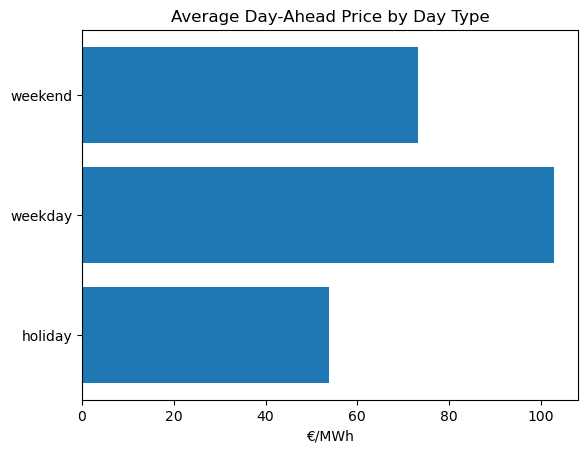

In [62]:
!pip install holidays
import holidays

# extract holidays for Germany for time period in our data set
years = range(df.index.year.min(), df.index.year.max() + 1)
de_holidays = holidays.Germany(years=years)

# assign day types
df['is_holiday'] = pd.Series(df.index.date, index=df.index).isin(de_holidays)
df['is_weekend'] = df.index.weekday >= 5
df['is_weekday'] = ~df['is_weekend']
df['day_type'] = 'weekday'
df.loc[df['is_weekend'], 'day_type'] = 'weekend'
df.loc[df['is_holiday'], 'day_type'] = 'holiday'

day_type_prices_avg = df.groupby('day_type')['day_ahead_price'].mean().reset_index()

plt.figure()
plt.barh(day_type_prices_avg['day_type'], day_type_prices_avg['day_ahead_price'])
plt.xlabel('€/MWh')
plt.title('Average Day-Ahead Price by Day Type')
plt.show()

**Interpretation:** the above mentioned expectations are confirmed.
* Weekdays: higher industrial and commercial demand -> higher prices
* Weekends: reduced economic activity -> lower demand -> lower prices
* Public holidays: demand often drops even further than on weekends

This motivates adding day type as a model parameter.